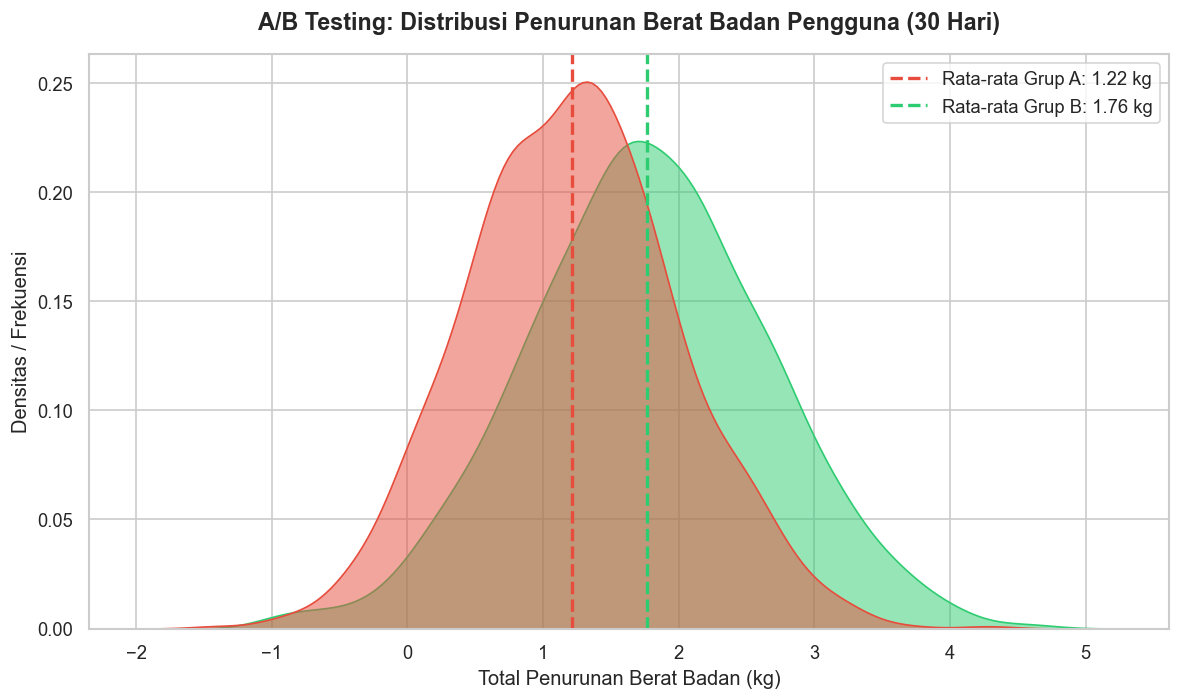

--------------------------------------------------
📊 HASIL EVALUASI A/B TESTING
--------------------------------------------------
Rata-rata Grup A (Kontrol)   : 1.22 kg
Rata-rata Grup B (Treatment) : 1.76 kg
P-Value                      : 0.00000
--------------------------------------------------
✅ KESIMPULAN SIGNIFIKAN: P-Value < 0.05.
Hipotesis terbukti! Fitur 'FitSmart AI Dashboard' secara signifikan membantu pengguna menurunkan berat badan lebih banyak dibandingkan pelacak standar.
Rekomendasi Bisnis: Segera Roll-out fitur ini ke 100% pengguna aplikasi.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. SETUP DATA A/B TESTING (MOCKUP EKSPERIMEN 30 HARI)
# ==============================================================================
np.random.seed(42)
n_users = 1000 # Total 2000 user yang ikut eksperimen

# Group A (Control): User yang menggunakan pelacak standar (tanpa Dashboard AI)
# Asumsi rata-rata turun 1.2 kg dalam 30 hari, std = 0.8
group_a_loss = np.random.normal(loc=1.2, scale=0.8, size=n_users)

# Group B (Treatment): User yang menggunakan FitSmart AI Dashboard (ARIMA + TDEE Tracker)
# Asumsi rata-rata turun 1.7 kg dalam 30 hari, std = 0.9
group_b_loss = np.random.normal(loc=1.7, scale=0.9, size=n_users)

df_ab = pd.DataFrame({
    'Grup': ['A (Kontrol - Standar)'] * n_users + ['B (Treatment - AI Dashboard)'] * n_users,
    'Penurunan_BB_Kg': np.concatenate([group_a_loss, group_b_loss])
})

# ==============================================================================
# 2. UJI STATISTIK (INDEPENDENT T-TEST)
# ==============================================================================
t_stat, p_value = stats.ttest_ind(group_a_loss, group_b_loss, equal_var=False)

# ==============================================================================
# 3. VISUALISASI HASIL EKSPERIMEN
# ==============================================================================
plt.figure(figsize=(10, 6), dpi=120)
sns.set_theme(style='whitegrid', palette='muted')

sns.kdeplot(data=df_ab, x='Penurunan_BB_Kg', hue='Grup', fill=True, palette=['#e74c3c', '#2ecc71'], alpha=0.5)

plt.axvline(group_a_loss.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Rata-rata Grup A: {group_a_loss.mean():.2f} kg')
plt.axvline(group_b_loss.mean(), color='#2ecc71', linestyle='--', linewidth=2, label=f'Rata-rata Grup B: {group_b_loss.mean():.2f} kg')

plt.title('A/B Testing: Distribusi Penurunan Berat Badan Pengguna (30 Hari)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Penurunan Berat Badan (kg)', fontsize=12)
plt.ylabel('Densitas / Frekuensi', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. KESIMPULAN BISNIS
# ==============================================================================
print("-" * 50)
print("📊 HASIL EVALUASI A/B TESTING")
print("-" * 50)
print(f"Rata-rata Grup A (Kontrol)   : {group_a_loss.mean():.2f} kg")
print(f"Rata-rata Grup B (Treatment) : {group_b_loss.mean():.2f} kg")
print(f"P-Value                      : {p_value:.5f}")
print("-" * 50)

if p_value < 0.05:
    print("✅ KESIMPULAN SIGNIFIKAN: P-Value < 0.05.")
    print("Hipotesis terbukti! Fitur 'FitSmart AI Dashboard' secara signifikan membantu pengguna menurunkan berat badan lebih banyak dibandingkan pelacak standar.")
    print("Rekomendasi Bisnis: Segera Roll-out fitur ini ke 100% pengguna aplikasi.")
else:
    print("❌ KESIMPULAN TIDAK SIGNIFIKAN: P-Value >= 0.05.")
    print("Tidak ada perbedaan statistik yang nyata antara Grup A dan Grup B. Perlu iterasi ulang pada desain fitur atau edukasi pengguna.")